In [1]:
!pip install pyreadr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.3/788.3 kB 10.2 MB/s eta 0:00:00


In [2]:
import pyreadr
import warnings
import numpy             as np
import pandas            as pd
import statsmodels.api   as sm
import matplotlib.pyplot as plt
from scipy.stats                   import gamma, vonmises, geom
from scipy.optimize                import minimize
from statsmodels.graphics.tsaplots import plot_acf
warnings.filterwarnings("ignore") # Suppress optimizer math warnings

In [3]:
wildhaggis = pyreadr.read_r("haggis_data.RData")

df = wildhaggis['haggis_data']
df.to_csv('haggis_data.csv', index=False)
df.head()

,ID,x,y,slope,temp
0,1,0.000000,0.000000,25.957002,10.344959
1,1,-1.068761,-0.194650,18.606632,8.352531
2,1,-6.152549,2.051343,16.524004,13.529650
3,1,-6.703983,3.338480,9.154917,10.951095
4,1,-6.541667,3.553843,5.547686,11.243328


In [4]:
elk = pyreadr.read_r("elk_data.RData")
df = elk['elk_data']
df.to_csv("elk_data.csv")
df.head()

,ID,Easting,Northing,dist_water
0,elk-115,769928,4992847.0,200.00
1,elk-115,766875,4997444.0,600.52
2,elk-115,765949,4998516.0,561.81
3,elk-115,765938,4998276.5,550.00
4,elk-115,766275,4998005.0,302.08


# 1. DATA PREPROCESSING MODULE (Section 18.2 & 18.3)

In [5]:
def prep_movement_data(df, x_col, y_col):
    """
    Converts raw X/Y coordinates into Step Lengths and Turning Angles.
    Operates on each individual animal separately.
    """
    def process_group(group):
        # Calculate differences in coordinates
        dx = group[x_col].diff()
        dy = group[y_col].diff()

        # Step length is the Euclidean distance
        group['step_length'] = np.sqrt(dx**2 + dy**2)

        # Absolute angle of movement
        abs_angle = np.arctan2(dy, dx)

        # Turning angle is the change in absolute angle
        turning_angle = abs_angle.diff()

        # Wrap the turning angle to be strictly between -pi and pi
        turning_angle = (turning_angle + np.pi) % (2 * np.pi) - np.pi
        group['turning_angle'] = turning_angle

        return group

    # Apply math to each animal ID
    processed = df.groupby('ID').apply(process_group).reset_index(drop=True)

    # Drop rows with NaN (the first two rows of an animal's track lack turning angles)
    # Also drop steps that are exactly 0 to prevent Gamma distribution math errors
    final_data = processed.dropna(subset=['step_length', 'turning_angle'])
    final_data = final_data[final_data['step_length'] > 0.01].copy()

    return final_data

# 2. HMM LIKELIHOOD FUNCTIONS (2-State & 3-State) & VITERBI ALGORITHM


In [6]:
def calc_stationary(gamma_mat):
    n = gamma_mat.shape[0]
    try:
        return np.linalg.solve(np.eye(n) - gamma_mat.T + np.ones((n, n)), np.ones(n))
    except np.linalg.LinAlgError:
        return np.ones(n) / n

def hmm_2state_nll(params, steps, angles):
    shape1, scale1, shape2, scale2, mu1, kappa1, mu2, kappa2, p11, p22 = params
    gamma_mat = np.array([[p11, 1 - p11], [1 - p22, p22]])
    delta = calc_stationary(gamma_mat)

    p_s1 = gamma.pdf(steps, a=shape1, scale=scale1) * vonmises.pdf(angles, kappa=kappa1, loc=mu1)
    p_s2 = gamma.pdf(steps, a=shape2, scale=scale2) * vonmises.pdf(angles, kappa=kappa2, loc=mu2)
    all_probs = np.column_stack((p_s1, p_s2))

    log_lik = 0.0
    foo = delta * all_probs[0, :]
    sumfoo = np.sum(foo)
    if sumfoo <= 0: return np.inf
    log_lik += np.log(sumfoo)
    phi = foo / sumfoo

    for t in range(1, len(steps)):
        foo = np.dot(phi, gamma_mat) * all_probs[t, :]
        sumfoo = np.sum(foo)
        if sumfoo <= 0: return np.inf
        log_lik += np.log(sumfoo)
        phi = foo / sumfoo
    return -log_lik

def hmm_3state_nll(params, steps, angles):
    sh1, sc1, sh2, sc2, sh3, sc3, m1, k1, m2, k2, m3, k3 = params[0:12]
    p11, p12, p21, p22, p31, p32 = params[12:18]
    p13 = max(0, 1 - p11 - p12); p23 = max(0, 1 - p21 - p22); p33 = max(0, 1 - p31 - p32)

    gamma_mat = np.array([[p11, p12, p13], [p21, p22, p23], [p31, p32, p33]])
    gamma_mat = gamma_mat / gamma_mat.sum(axis=1, keepdims=True)
    delta = calc_stationary(gamma_mat)

    p_s1 = gamma.pdf(steps, a=sh1, scale=sc1) * vonmises.pdf(angles, kappa=k1, loc=m1)
    p_s2 = gamma.pdf(steps, a=sh2, scale=sc2) * vonmises.pdf(angles, kappa=k2, loc=m2)
    p_s3 = gamma.pdf(steps, a=sh3, scale=sc3) * vonmises.pdf(angles, kappa=k3, loc=m3)
    all_probs = np.column_stack((p_s1, p_s2, p_s3))

    log_lik, foo = 0.0, delta * all_probs[0, :]
    sumfoo = np.sum(foo)
    if sumfoo <= 0: return np.inf
    log_lik += np.log(sumfoo); phi = foo / sumfoo

    for t in range(1, len(steps)):
        foo = np.dot(phi, gamma_mat) * all_probs[t, :]
        sumfoo = np.sum(foo)
        if sumfoo <= 0: return np.inf
        log_lik += np.log(sumfoo); phi = foo / sumfoo
    return -log_lik

def viterbi_decode(params, steps, angles):
    T = len(steps)
    shape1, scale1, shape2, scale2, mu1, kappa1, mu2, kappa2, p11, p22 = params
    gamma_mat = np.array([[p11, 1 - p11], [1 - p22, p22]])

    p_s1 = gamma.pdf(steps, a=shape1, scale=scale1) * vonmises.pdf(angles, kappa=kappa1, loc=mu1)
    p_s2 = gamma.pdf(steps, a=shape2, scale=scale2) * vonmises.pdf(angles, kappa=kappa2, loc=mu2)
    all_probs = np.column_stack((p_s1, p_s2))

    xi = np.zeros((T, 2))
    v = np.zeros(T, dtype=int)

    foo = calc_stationary(gamma_mat) * all_probs[0, :]
    xi[0, :] = foo / np.sum(foo)
    for t in range(1, T):
        foo = np.max(xi[t-1, :][:, None] * gamma_mat, axis=0) * all_probs[t, :]
        xi[t, :] = foo / np.sum(foo)

    v[T-1] = np.argmax(xi[T-1, :])
    for t in reversed(range(T-1)):
        v[t] = np.argmax(gamma_mat[:, v[t+1]] * xi[t, :])
    return v

def predict_next_movement(params, current_state):
    """
    Forecasts the animal's next behavioral state, step length, and turning angle
    based on the optimized HMM parameters and its current state.
    """
    shape1, scale1, shape2, scale2, mu1, kappa1, mu2, kappa2, p11, p22 = params

    # Transition matrix
    gamma_mat = np.array([[p11, 1 - p11],
                          [1 - p22, p22]])

    # 1. Predict the Next State
    # Get the transition probabilities for the next step based on current state
    next_state_probs = gamma_mat[current_state]
    predicted_state = np.argmax(next_state_probs) # Returns 0 (State 1) or 1 (State 2)

    # 2. Predict the Movement Values (Expected Values)
    # Expected Step Length for Gamma = shape * scale
    # Expected Turn Angle for von Mises = mu
    if predicted_state == 0:
        expected_step = shape1 * scale1
        expected_turn = mu1
        state_name = "State 1 (Encamped / Resting)"
    else:
        expected_step = shape2 * scale2
        expected_turn = mu2
        state_name = "State 2 (Exploring / Moving)"

    print("\n" + "~"*60)
    print("🔮 FORECAST FOR NEXT MOVEMENT (T + 1)")
    print("~"*60)
    print(f"Current Status      : {'State 1 (Resting)' if current_state==0 else 'State 2 (Exploring)'}")
    print(f"Prob. of State 1    : {next_state_probs[0]*100:.2f}%")
    print(f"Prob. of State 2    : {next_state_probs[1]*100:.2f}%")
    print(f"-> Predicted State  : {state_name}")
    print(f"-> Expected Speed   : {expected_step:.2f} units (Step Length)")
    print(f"-> Expected Heading : {expected_turn:.3f} radians (Turning Angle)")
    print("~"*60 + "\n")

    return predicted_state, expected_step, expected_turn

In [7]:
def plot_comprehensive_diagnostics(track, p, steps, angles, animal_id, x_col, y_col):
    """Generates all 4 textbook charts for a given animal track."""

    # 1. LOESS & ACF (Figures 18.3 & 18.4)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(steps, angles, s=2, color='grey', alpha=0.5)
    lowess = sm.nonparametric.lowess(angles, steps, frac=0.3)
    axes[0].plot(lowess[:, 0], lowess[:, 1], color='black', lw=2)
    axes[0].set_title(f"Turn Angle vs Step Length ({animal_id})")
    plot_acf(steps, ax=axes[1], lags=10, title=f"ACF of Step Length ({animal_id})")
    plt.tight_layout(); plt.show()

    # 2. Histogram Distributions (Figure 18.6)
    delta = calc_stationary(np.array([[p[8], 1-p[8]], [1-p[9], p[9]]]))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    x_steps = np.linspace(0.01, np.percentile(steps, 95), 200)
    pdf1_s = gamma.pdf(x_steps, a=p[0], scale=p[1])
    pdf2_s = gamma.pdf(x_steps, a=p[2], scale=p[3])
    axes[0].hist(steps, bins=40, density=True, color='lightgrey', alpha=0.7)
    axes[0].plot(x_steps, pdf1_s * delta[0], 'r--', label='State 1 (Encamped)')
    axes[0].plot(x_steps, pdf2_s * delta[1], 'b-.', label='State 2 (Explore)')
    axes[0].plot(x_steps, delta[0]*pdf1_s + delta[1]*pdf2_s, 'k-', label='Marginal')
    axes[0].set_title(f"Step Lengths ({animal_id})"); axes[0].legend()

    x_angles = np.linspace(-np.pi, np.pi, 200)
    pdf1_a = vonmises.pdf(x_angles, kappa=p[5], loc=p[4])
    pdf2_a = vonmises.pdf(x_angles, kappa=p[7], loc=p[6])
    axes[1].hist(angles, bins=30, density=True, color='lightgrey', alpha=0.7)
    axes[1].plot(x_angles, pdf1_a * delta[0], 'r--', label='State 1')
    axes[1].plot(x_angles, pdf2_a * delta[1], 'b-.', label='State 2')
    axes[1].plot(x_angles, delta[0]*pdf1_a + delta[1]*pdf2_a, 'k-', label='Marginal')
    axes[1].set_title(f"Turning Angles ({animal_id})")
    plt.tight_layout(); plt.show()

    # 3. Viterbi GPS Map
    states = viterbi_decode(p, steps, angles)
    last_known_state = states[-1]
    predict_next_movement(p, last_known_state)
    track['State'] = states + 1
    s1_pts = track[track['State'] == 1]
    s2_pts = track[track['State'] == 2]

    plt.figure(figsize=(8, 6))
    plt.plot(track[x_col], track[y_col], color='grey', lw=1, zorder=1)
    plt.scatter(s1_pts[x_col], s1_pts[y_col], c='red', label='State 1 (Resting)', zorder=2)
    plt.scatter(s2_pts[x_col], s2_pts[y_col], c='blue', label='State 2 (Exploring)', zorder=2)
    plt.title(f"Viterbi GPS Map for {animal_id}")
    plt.xlabel(x_col); plt.ylabel(y_col); plt.legend(); plt.show()

    # 4. Empirical vs Geometric Dwell Times (Figure 18.7)
    runs, current_state, current_len = [], states[0], 1
    for s in states[1:]:
        if s == current_state: current_len += 1
        else:
            runs.append((current_state, current_len))
            current_state, current_len = s, 1
    runs.append((current_state, current_len))

    state1_dwells = [r[1] for r in runs if r[0] == 0]

    if len(state1_dwells) > 0:
        plt.figure(figsize=(6, 4))
        max_val = min(max(state1_dwells), 25)
        t = np.arange(1, max_val + 1)
        theo_geom = geom.pmf(t, 1 - p[8])

        plt.hist(state1_dwells, bins=range(1, max_val+2), density=True, alpha=0.5, color='gray', label='Actual Dwell Times')
        plt.plot(t, theo_geom, 'r-o', label=f'HMM Geometric (p11={p[8]:.2f})')
        plt.title(f"Dwell-Time Check for {animal_id} (Figure 18.7)")
        plt.xlabel("Consecutive Steps in Encamped State"); plt.ylabel("Probability")
        plt.legend()
        plt.show()

# MODEL 1: CASE 1 (HAGGIS) - BASELINE MODEL SELECTION

In [8]:
def run_case1_basic_hmm(data, x_col, y_col):
    print("\n" + "="*60 + "\nMODEL 1: BASIC HMM (HAGGIS - CHAPTER 18.4)\n" + "="*60)
    steps, angles = data['step_length'].values, data['turning_angle'].values
    N = len(steps)

    guess_2s = [1.0, 2.0, 2.0, 5.0, 0.0, 0.1, 0.0, 2.0, 0.8, 0.8]
    b_2s = [(0.01, None)]*4 + [(-np.pi, np.pi), (0.01, 10)]*2 + [(0.01, 0.99)]*2

    guess_3s = [1.0, 1.0, 1.5, 3.0, 2.0, 6.0, 0.0, 0.1, 0.0, 0.5, 0.0, 2.0, 0.4, 0.3, 0.3, 0.4, 0.2, 0.3]
    b_3s = [(0.01, None)]*6 + [(-np.pi, np.pi), (0.01, 10)]*3 + [(0.01, 0.8)]*6

    print("Optimizing 2-State Model...")
    res_2s = minimize(hmm_2state_nll, guess_2s, args=(steps, angles), method='L-BFGS-B', bounds=b_2s)

    print("Optimizing 3-State Model...")
    res_3s = minimize(hmm_3state_nll, guess_3s, args=(steps, angles), method='L-BFGS-B', bounds=b_3s)

    # Replicating Table 18.1
    print("\nTABLE 18.1: AIC/BIC Comparison")
    print(f"{'No. states':<15} | {'Params':<10} | {'Log-Likelihood':<15} | {'AIC':<10} | {'BIC':<10}")
    for i, res, k in [(2, res_2s, 10), (3, res_3s, 18)]:
        nll = res.fun
        print(f"{i:<15} | {k:<10} | {-nll:<15.2f} | {2*k + 2*nll:<10.2f} | {k*np.log(N) + 2*nll:<10.2f}")

    p = res_2s.x
    print("\n" + "="*70 + f"\nTABLE 18.2: 2-State Final Parameters \n" + "="*70)
    print(f"{'State':<15} | {'Step Mean':<12} | {'Step Var':<12} | {'Turn Angle (Mu)':<18} | {'Turn Conc (Kappa)':<18}")
    print(f"{'1 (Encamped)':<15} | {p[0]*p[1]:<12.2f} | {p[0]*(p[1]**2):<12.2f} | {p[4]:<18.3f} | {p[5]:<18.3f}")
    print(f"{'2 (Explore)':<15} | {p[2]*p[3]:<12.2f} | {p[2]*(p[3]**2):<12.2f} | {p[6]:<18.3f} | {p[7]:<18.3f}")
    print("="*70)

# Chart A: LOESS Scatter (Figure 18.3) & ACF (Figure 18.4)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(steps, angles, s=2, color='grey', alpha=0.5)
    lowess = sm.nonparametric.lowess(angles, steps, frac=0.3)
    axes[0].plot(lowess[:, 0], lowess[:, 1], color='black', lw=2)
    axes[0].set_title("Turn Angle vs Step Length")
    plot_acf(steps, ax=axes[1], lags=10, title="ACF of Step Length")
    plt.tight_layout()
    plt.show()

    # Chart B: Histogram distributions (Figure 18.6/18.8)
    delta = calc_stationary(np.array([[p[8], 1-p[8]], [1-p[9], p[9]]]))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    x_steps = np.linspace(0.01, np.percentile(steps, 95), 200)
    pdf1 = gamma.pdf(x_steps, a=p[0], scale=p[1])
    pdf2 = gamma.pdf(x_steps, a=p[2], scale=p[3])
    axes[0].hist(steps, bins=40, density=True, color='lightgrey', alpha=0.7)
    axes[0].plot(x_steps, pdf1 * delta[0], 'r--', label='State 1 (Encamped)')
    axes[0].plot(x_steps, pdf2 * delta[1], 'b-.', label='State 2 (Explore)')
    axes[0].plot(x_steps, delta[0]*pdf1 + delta[1]*pdf2, 'k-', label='Marginal')
    axes[0].set_title("Step Length Distributions"); axes[0].legend()

    x_angles = np.linspace(-np.pi, np.pi, 200)
    pdf1_a = vonmises.pdf(x_angles, kappa=p[5], loc=p[4])
    pdf2_a = vonmises.pdf(x_angles, kappa=p[7], loc=p[6])
    axes[1].hist(angles, bins=30, density=True, color='lightgrey', alpha=0.7)
    axes[1].plot(x_angles, pdf1_a * delta[0], 'r--', label='State 1')
    axes[1].plot(x_angles, pdf2_a * delta[1], 'b-.', label='State 2')
    axes[1].plot(x_angles, delta[0]*pdf1_a + delta[1]*pdf2_a, 'k-', label='Marginal')
    axes[1].set_title("Turning Angle Distributions")
    plt.tight_layout()
    plt.show()

    # Chart C: The colored VITERBI GPS MAP
    data['State'] = viterbi_decode(p, steps, angles) + 1 # Decode states!
    animal = data['ID'].unique()[0]
    track = data[data['ID'] == animal]
    s1_pts = track[track['State'] == 1]
    s2_pts = track[track['State'] == 2]

    plt.figure(figsize=(8, 6))
    plt.plot(track[x_col], track[y_col], color='grey', lw=1, zorder=1)
    plt.scatter(s1_pts[x_col], s1_pts[y_col], c='red', label='State 1 (Encamped/Rest)', zorder=2)
    plt.scatter(s2_pts[x_col], s2_pts[y_col], c='blue', label='State 2 (Exploring/Move)', zorder=2)
    plt.title(f"Viterbi GPS Map for {animal} (Colored by HMM Behavior)")
    plt.xlabel("X Coordinate"); plt.ylabel("Y Coordinate")
    plt.legend()
    plt.show()

# MODEL 2: CASE 2 (ELK) - DWELL TIME / HSMM JUSTIFICATION


In [9]:
def run_case2_hsmm(data):
    print("\n" + "="*60 + "\nMODEL 2: DWELL TIMES / HSMM JUSTIFICATION (ELK - CH 18.5)\n" + "="*60)

    animal_id = 'elk-115'
    track = data[data['ID'] == animal_id].copy()
    steps, angles = track['step_length'].values, track['turning_angle'].values

    guess_2s = [1.0, 100.0, 2.0, 300.0, 0.0, 0.1, 0.0, 1.5, 0.8, 0.8]
    b_2s = [(0.01, None)]*4 + [(-np.pi, np.pi), (0.01, 10)]*2 + [(0.01, 0.99)]*2

    print("Fitting 2-State Model to extract Transition Probabilities...")
    res = minimize(hmm_2state_nll, guess_2s, args=(steps, angles), method='L-BFGS-B', bounds=b_2s)
    p = res.x

    print(f"-> Probability of staying in State 1 (p11): {p[8]:.4f}")

    # Generate all charts (including Dwell Times)
    plot_comprehensive_diagnostics(track, p, steps, angles, animal_id, 'Easting', 'Northing')

# MODEL 3: CASE 3 (ELK) - MIXED HMM / HETEROGENEITY


In [10]:
def run_case3_mixed_hmm(data):
    print("\n" + "="*60 + "\nMODEL 3: POPULATION HETEROGENEITY (ELK - CH 18.6)\n" + "="*60)
    print("Fitting models to individual animals to demonstrate variance...")

    guess_2s = [1.0, 100.0, 2.0, 300.0, 0.0, 0.1, 0.0, 1.5, 0.8, 0.8]
    b_2s = [(0.01, None)]*4 + [(-np.pi, np.pi), (0.01, 10)]*2 + [(0.01, 0.99)]*2

    # Get all unique IDs, but REMOVE 'elk-115' because we used it in Model 2
    all_ids = data['ID'].unique()
    other_ids = [uid for uid in all_ids if uid != 'elk-115']

    # We will pick the next 2 distinct elks to compare visually
    unique_ids = other_ids[:2]

    print(f"\n{'Animal ID':<15} | {'p11 (Stay Encamped)':<20} | {'p22 (Stay Exploring)':<20}")
    print("-" * 60)

    for animal_id in unique_ids:
        track = data[data['ID'] == animal_id].copy()
        steps, angles = track['step_length'].values, track['turning_angle'].values

        # Fit model specifically to this animal
        res = minimize(hmm_2state_nll, guess_2s, args=(steps, angles), method='L-BFGS-B', bounds=b_2s)
        p = res.x

        print(f"{animal_id:<15} | {p[8]:<20.3f} | {p[9]:<20.3f}")

        print(f"\n---> Generating Visual Analysis for {animal_id}...")
        # Generate all charts for this specific elk!
        plot_comprehensive_diagnostics(track, p, steps, angles, animal_id, 'Easting', 'Northing')

    print("-" * 60)
    print("CONCLUSION: As seen in the charts and parameters above, movement")
    print("dynamics vary significantly across individuals. A Mixed HMM with Random")
    print("Effects is necessary to accurately capture population-level dynamics.")

In [11]:
if __name__ == "__main__":
        # Load Data
        haggis_df = pd.read_csv('haggis_data.csv')
        elk_df = pd.read_csv('elk_data.csv')

        haggis_data = prep_movement_data(haggis_df, 'x', 'y')
        elk_data = prep_movement_data(elk_df, 'Easting', 'Northing')


MODEL 1: BASIC HMM (HAGGIS - CHAPTER 18.4)
Optimizing 2-State Model...
Optimizing 3-State Model...

TABLE 18.1: AIC/BIC Comparison
No. states      | Params     | Log-Likelihood  | AIC        | BIC       
2               | 10         | -3456.01        | 6932.02    | 6982.87   
3               | 18         | -3456.96        | 6949.92    | 7041.45   

TABLE 18.2: 2-State Final Parameters 
State           | Step Mean    | Step Var     | Turn Angle (Mu)    | Turn Conc (Kappa) 
1 (Encamped)    | 1.00         | 0.24         | -3.110             | 1.035             
2 (Explore)     | 5.02         | 9.25         | -0.308             | 8.734             


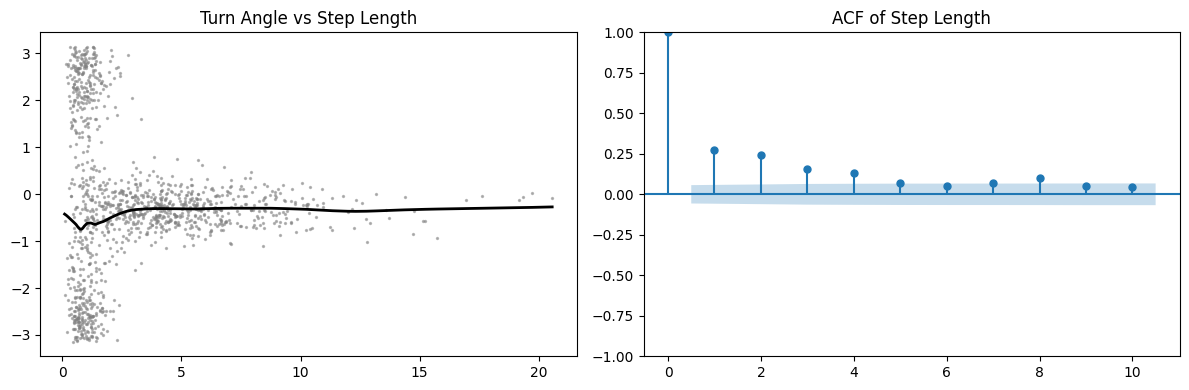

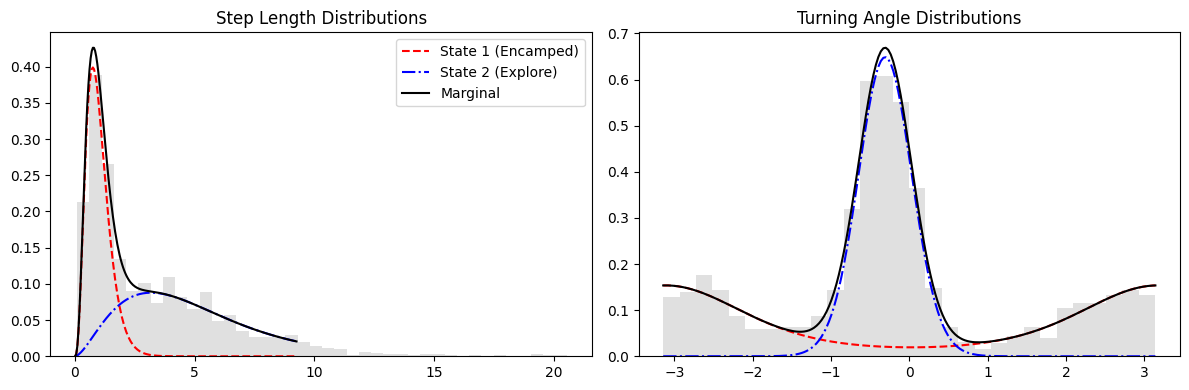

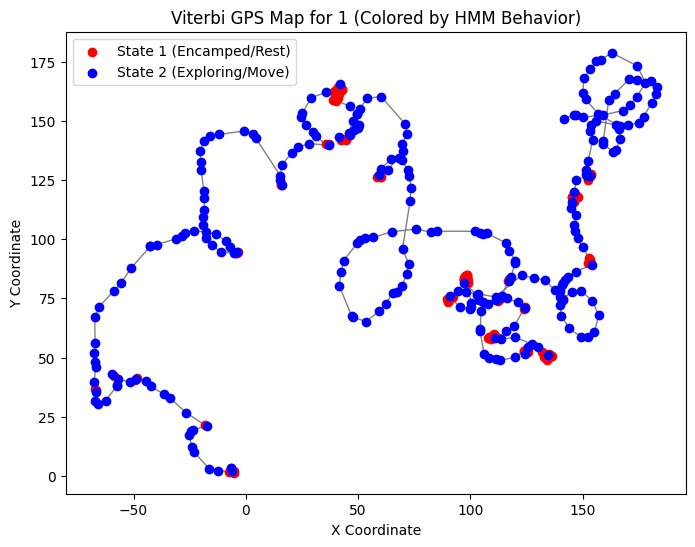

In [12]:
# Model 1 (Case 1: Basic HMM on Haggis)
run_case1_basic_hmm(haggis_data, 'x', 'y')


MODEL 2: DWELL TIMES / HSMM JUSTIFICATION (ELK - CH 18.5)
Fitting 2-State Model to extract Transition Probabilities...
-> Probability of staying in State 1 (p11): 0.9606


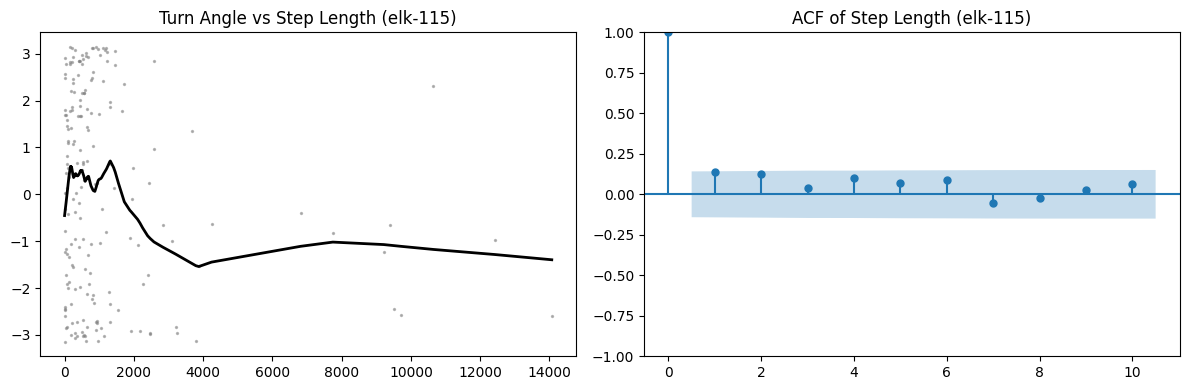

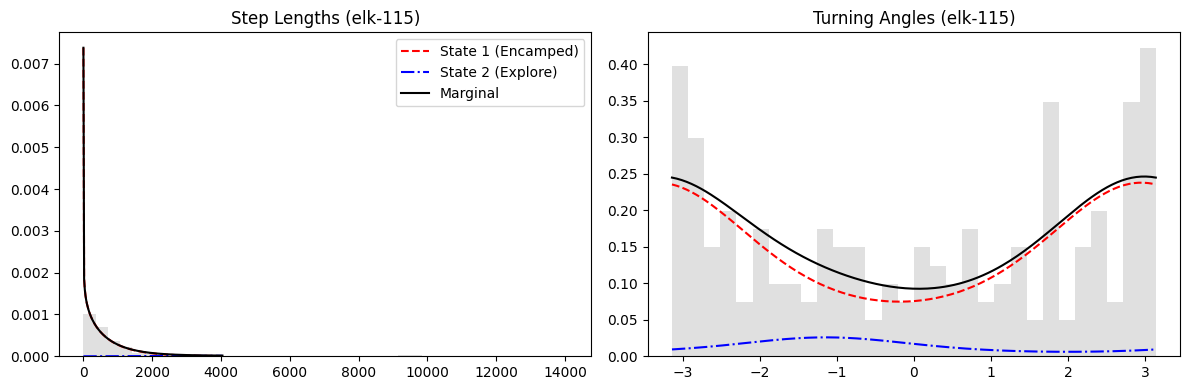


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
🔮 FORECAST FOR NEXT MOVEMENT (T + 1)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Current Status      : State 1 (Resting)
Prob. of State 1    : 96.06%
Prob. of State 2    : 3.94%
-> Predicted State  : State 1 (Encamped / Resting)
-> Expected Speed   : 666.15 units (Step Length)
-> Expected Heading : 2.953 radians (Turning Angle)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~



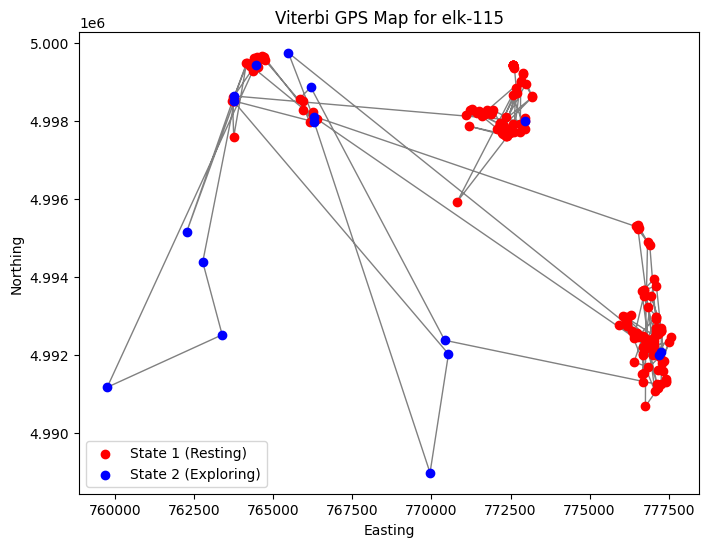

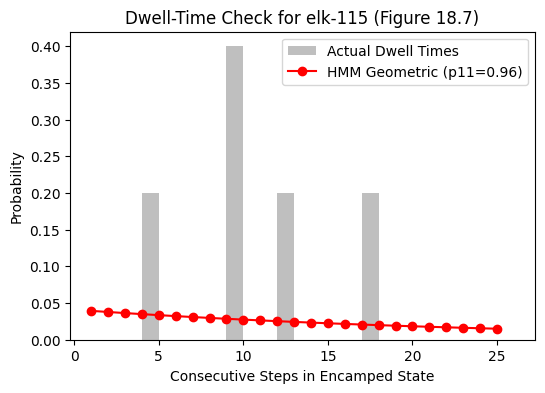

In [13]:
# Model 2 (Case 2: HSMM Check on Elk)
run_case2_hsmm(elk_data)


MODEL 3: POPULATION HETEROGENEITY (ELK - CH 18.6)
Fitting models to individual animals to demonstrate variance...

Animal ID       | p11 (Stay Encamped)  | p22 (Stay Exploring)
------------------------------------------------------------
elk-163         | 0.937                | 0.262               

---> Generating Visual Analysis for elk-163...


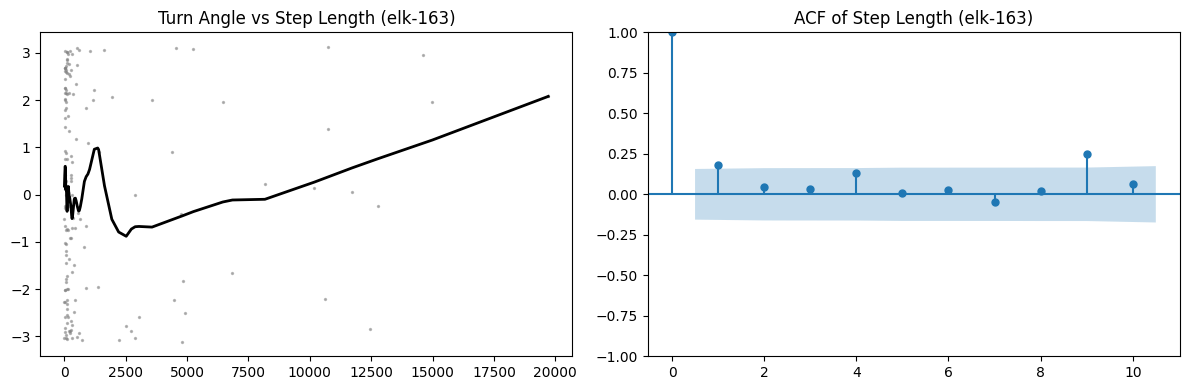

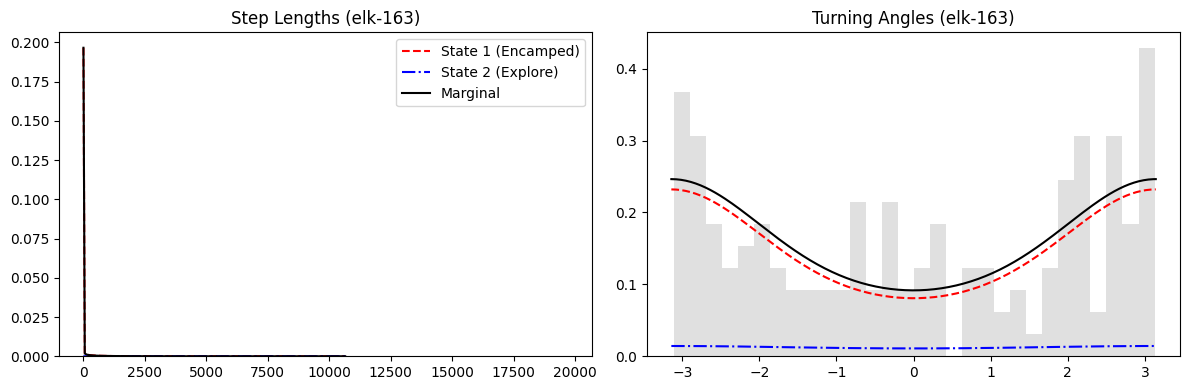


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
🔮 FORECAST FOR NEXT MOVEMENT (T + 1)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Current Status      : State 1 (Resting)
Prob. of State 1    : 93.68%
Prob. of State 2    : 6.32%
-> Predicted State  : State 1 (Encamped / Resting)
-> Expected Speed   : 676.45 units (Step Length)
-> Expected Heading : 3.142 radians (Turning Angle)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~



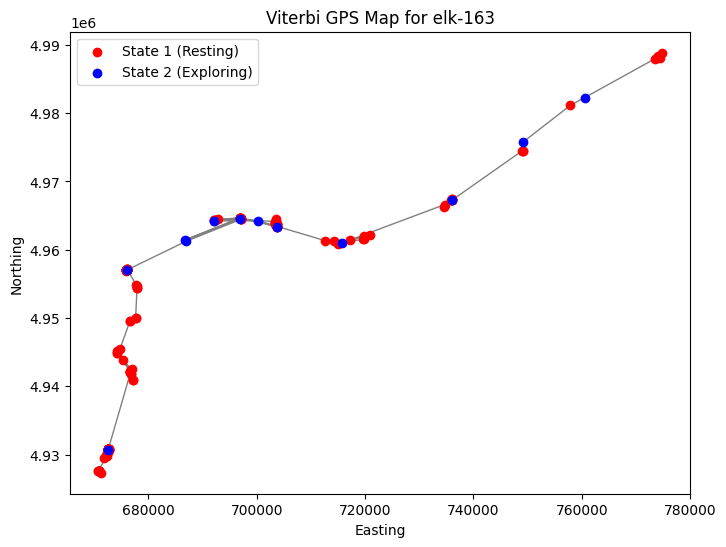

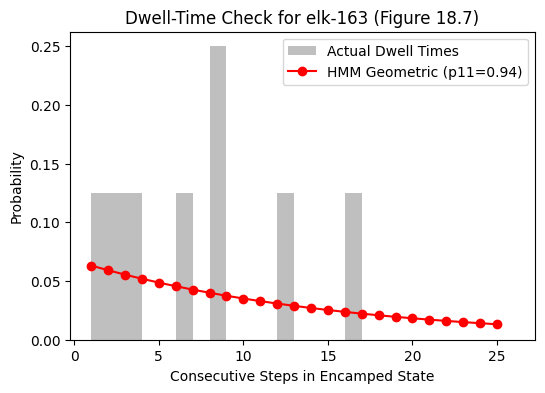

elk-287         | 0.914                | 0.672               

---> Generating Visual Analysis for elk-287...


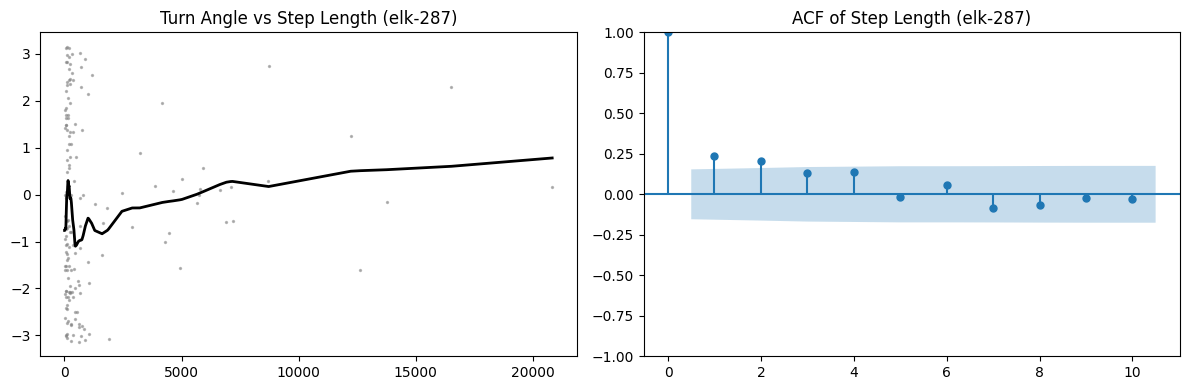

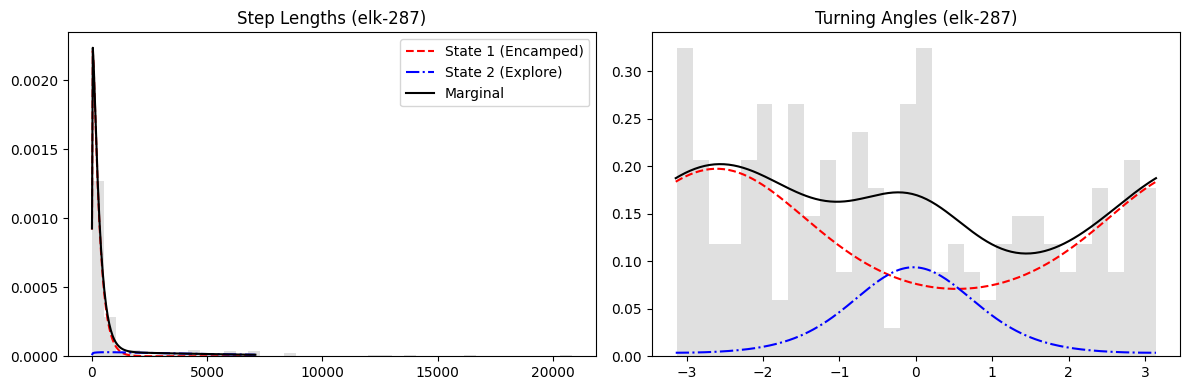


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
🔮 FORECAST FOR NEXT MOVEMENT (T + 1)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Current Status      : State 1 (Resting)
Prob. of State 1    : 91.43%
Prob. of State 2    : 8.57%
-> Predicted State  : State 1 (Encamped / Resting)
-> Expected Speed   : 291.11 units (Step Length)
-> Expected Heading : -2.606 radians (Turning Angle)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~



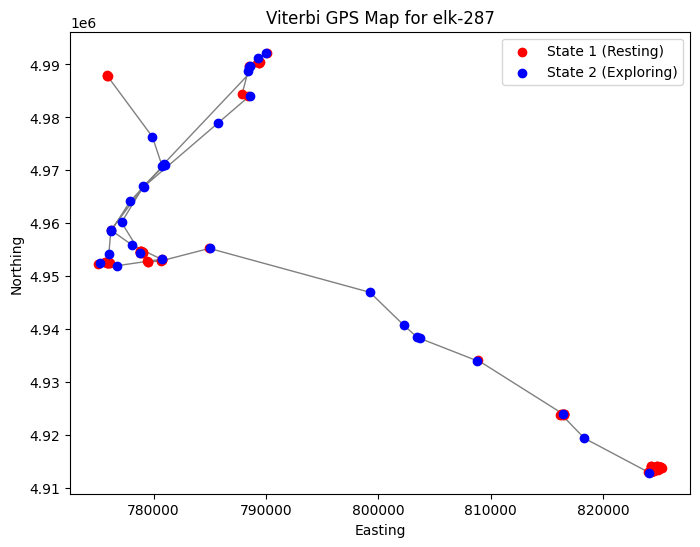

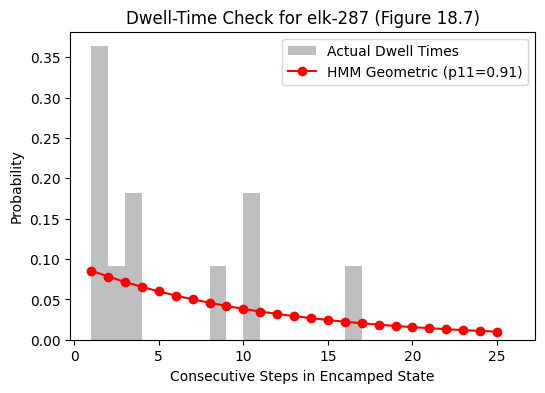

------------------------------------------------------------
CONCLUSION: As seen in the charts and parameters above, movement
dynamics vary significantly across individuals. A Mixed HMM with Random
Effects is necessary to accurately capture population-level dynamics.


In [14]:
 # Model 3 (Case 3: Mixed HMM Check on Elk)
run_case3_mixed_hmm(elk_data)